# Entrenamiento del Modelo Base

Este notebook entrena un clasificador binario (real vs. deepfake) usando fine-tuning sobre FaceForensics++.
Se comparan dos arquitecturas: **Xception** y **EfficientNet-B4**.

El mejor modelo de cada arquitectura se guarda como checkpoint para usar en el experimento de generalización cruzada.

## 1. Dependencias y configuración

In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchvision', 'timm', 'albumentations',
    'matplotlib', 'seaborn', 'pandas', 'scikit-learn',
    'opencv-python', 'tqdm'])

0

In [2]:
from pathlib import Path
import torch
import torch.nn as nn
import pandas as pd

from src.config import make_config, set_seed
from src.data import build_frame_dataframe, make_loaders
from src.models import build_model, build_optimizer
from src.engine import train_model, evaluate_test
from src.viz import plot_history
from sklearn.metrics import accuracy_score, f1_score

In [3]:
CONFIG = make_config(NUM_WORKERS=4, PATIENCE=5)
set_seed(CONFIG['SEED'])
print(f"Device: {CONFIG['DEVICE']}")
CONFIG

Device: cuda


{'DATA_DIR': PosixPath('/home/ramoss/dataset_split'),
 'OUTPUT_DIR': PosixPath('/home/ramoss/outputs'),
 'SEED': 42,
 'IMG_SIZE': 299,
 'BATCH_SIZE': 32,
 'LR': 0.0001,
 'LR_HEAD': 0.001,
 'WEIGHT_DECAY': 0.0001,
 'EPOCHS': 15,
 'PATIENCE': 5,
 'DROPOUT': 0.3,
 'NUM_WORKERS': 4,
 'DEVICE': 'cuda'}

## 2. Dataset y DataLoaders

In [4]:
df = build_frame_dataframe(CONFIG['DATA_DIR'])
print(f'Total frames: {len(df):,}')
print(df.groupby(['split', 'label']).size().unstack(fill_value=0))

Total frames: 60,000
label     0      1
split             
test   1400   7000
train  7200  36000
val    1400   7000


In [5]:
train_loader, val_loader, test_loader = make_loaders(df, CONFIG)

Train: 43,200 | Val: 8,400 | Test: 8,400


## 3. Definición del modelo

Se usa **Xception** como arquitectura principal, que es el baseline reportado en el paper original de FaceForensics++.
Como comparación se entrena también **EfficientNet-B4**, una arquitectura más reciente con menor número de parámetros (en el siguiente notebook).

En ambos casos se aplica fine-tuning completo (todos los parámetros entrenables) con una tasa de aprendizaje diferenciada: mayor para la capa de clasificación final y menor para el resto de la red.

In [6]:
model = build_model('xception', CONFIG['DEVICE'])
optimizer = build_optimizer(model, CONFIG['LR'], CONFIG['LR_HEAD'], CONFIG['WEIGHT_DECAY'])
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['EPOCHS'], eta_min=1e-6
)

/home/ramoss/vision-env/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


xception — parámetros entrenables: 20,809,001


## 4. Loop de entrenamiento

In [7]:
print('Entrenando Xception')
history_xception = train_model(
    model, 'xception', train_loader, val_loader,
    optimizer, criterion, scheduler, CONFIG
)

Entrenando Xception


Epoch 01/15 | train_loss=0.6494 train_acc=0.5820 | val_loss=0.5816 val_acc=0.6773 val_auc=0.7583  ✓ checkpoint guardado (AUC=0.7583)


Epoch 02/15 | train_loss=0.4933 train_acc=0.7345 | val_loss=0.5287 val_acc=0.7573 val_auc=0.7946  ✓ checkpoint guardado (AUC=0.7946)


Epoch 03/15 | train_loss=0.3930 train_acc=0.8006 | val_loss=0.5166 val_acc=0.7868 val_auc=0.8111  ✓ checkpoint guardado (AUC=0.8111)


Epoch 04/15 | train_loss=0.3328 train_acc=0.8323 | val_loss=0.5258 val_acc=0.8267 val_auc=0.7967  (sin mejora 1/5)


...

Epoch 07/15 | train_loss=0.2362 train_acc=0.8814 | val_loss=0.7689 val_acc=0.8292 val_auc=0.8213  (sin mejora 1/5)


Epoch 08/15 | train_loss=0.2131 train_acc=0.8930 | val_loss=0.7639 val_acc=0.8254 val_auc=0.8174  (sin mejora 2/5)


Epoch 09/15 | train_loss=0.1948 train_acc=0.8979 | val_loss=0.8949 val_acc=0.8302 val_auc=0.8151  (sin mejora 3/5)


Epoch 10/15 | train_loss=0.1800 train_acc=0.9054 | val_loss=0.9888 val_acc=0.8400 val_auc=0.8105  (sin mejora 4/5)


Epoch 11/15 | train_loss=0.1677 train_acc=0.9099 | val_loss=1.0981 val_acc=0.8354 val_auc=0.8149  (sin mejora 5/5)

Early stopping en época 11.


## 5. Curvas de entrenamiento

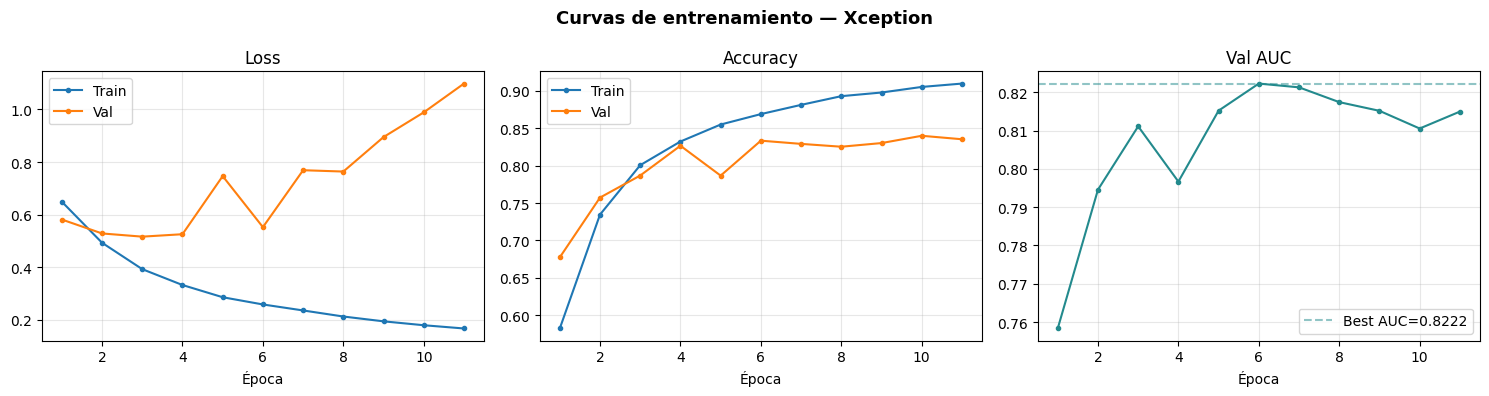

In [8]:
plot_history(history_xception, 'Xception', CONFIG['OUTPUT_DIR'])

## 6. Evaluación en test set

Test: 100%|██████████████████████████████████████████████████████████████████████████| 263/263 [01:03<00:00,  4.11it/s]



── xception — Test AUC: 0.8237 ──
              precision    recall  f1-score   support

        real       0.49      0.53      0.51      1400
        fake       0.90      0.89      0.90      7000

    accuracy                           0.83      8400
   macro avg       0.69      0.71      0.70      8400
weighted avg       0.83      0.83      0.83      8400



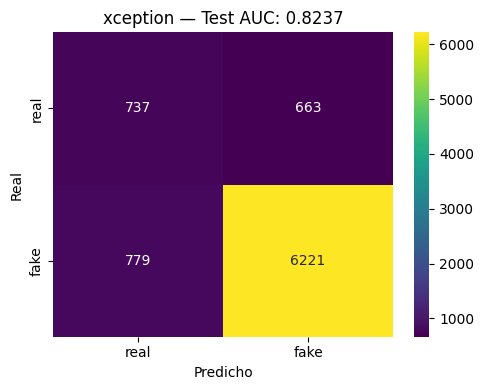

In [9]:
auc_xception, preds_xception, targets_test, probs_xception = evaluate_test(
    model, 'xception', test_loader, CONFIG['DEVICE'], CONFIG['OUTPUT_DIR']
)

In [10]:
results_xception = pd.DataFrame([{
    'Modelo': 'Xception',
    'AUC-ROC (test)': round(auc_xception, 4),
    'Accuracy (test)': round(accuracy_score(targets_test, preds_xception), 4),
    'F1 (fake)': round(f1_score(targets_test, preds_xception), 4),
    'Best Val AUC': round(history_xception['val_auc'].max(), 4),
    'Épocas entrenadas': len(history_xception),
}])
results_xception.to_csv(CONFIG['OUTPUT_DIR'] / 'results_xception.csv', index=False)